In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#import dataset directly from github repo
url='https://raw.githubusercontent.com/nivetha486/24ADI204_DSV_Team12/refs/heads/main/Complete_Updated_Autoimmune_Disorder_Dataset.csv'
df = pd.read_csv(url)
display(df.head())

,Patient_ID,Age,Gender,Diagnosis,Sickness_Duration_Months,RBC_Count,Hemoglobin,Hematocrit,MCV,MCH,...,Anti_epidermal_basement_membrane_IgA,Anti_OmpC,pANCA,Anti_tissue_transglutaminase,anti_Scl_70,Anti_Mi2,Anti_parietal_cell,Progesterone_antibodies,Anti_Sm,MBL
0,6,62,Male,Autoimmune orchitis,41,4.75,13.37,43.11,101.91,28.41,...,0,0,0,0,0,0,0,0,0,0.051675
1,20,54,Female,Autoimmune orchitis,41,4.32,10.76,39.92,95.96,28.22,...,0,0,0,0,0,0,0,0,0,0.065344
2,46,34,Male,Autoimmune orchitis,86,4.42,11.91,38.38,80.56,28.40,...,0,0,0,0,0,0,0,0,0,0.126083
3,108,22,Male,Autoimmune orchitis,43,4.33,12.72,39.99,84.71,26.67,...,0,0,0,0,0,0,0,0,0,0.251571
4,142,20,Female,Autoimmune orchitis,50,3.99,11.07,43.58,89.87,30.64,...,0,0,0,0,0,0,0,0,0,0.459332


In [ ]:
#info about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13812 entries, 0 to 13811
Data columns (total 80 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Patient_ID                            13812 non-null  int64  
 1   Age                                   13812 non-null  int64  
 2   Gender                                13812 non-null  object 
 3   Diagnosis                             13812 non-null  object 
 4   Sickness_Duration_Months              13812 non-null  int64  
 5   RBC_Count                             13812 non-null  float64
 6   Hemoglobin                            13812 non-null  float64
 7   Hematocrit                            13812 non-null  float64
 8   MCV                                   13812 non-null  float64
 9   MCH                                   13812 non-null  float64
 10  MCHC                                  13812 non-null  float64
 11  RDW            

In [ ]:
df.isnull().sum()

,0
Patient_ID,0
Age,0
Gender,0
Diagnosis,0
Sickness_Duration_Months,0
...,...
Anti_Mi2,0
Anti_parietal_cell,0
Progesterone_antibodies,0
Anti_Sm,0


In [ ]:
df.dropna(how='all')
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

Number of duplicate rows: 0


In [ ]:
# Remove exact duplicates
df = df.drop_duplicates()

# Check numerical statistics
print(df.describe())

# Check categorical values
print(df["Gender"].value_counts())
print(df["Diagnosis"].value_counts())

# Final checks
print(df.shape)

         Patient_ID           Age  Sickness_Duration_Months     RBC_Count  \
count  13812.000000  13812.000000              13812.000000  13812.000000   
mean    4943.404431     49.507023                 62.589125      4.413987   
std     2973.417945     17.659349                 33.604675      0.555170   
min        6.000000     20.000000                  1.000000      3.510000   
25%     2333.250000     34.000000                 34.000000      3.960000   
50%     5192.000000     48.000000                 62.000000      4.400000   
75%     7605.000000     66.000000                 91.000000      4.810000   
max     9999.000000     79.000000                119.000000      6.099889   

         Hemoglobin    Hematocrit           MCV           MCH          MCHC  \
count  13812.000000  13812.000000  13812.000000  13812.000000  13812.000000   
mean      12.855142     41.071055     89.791482     29.218271     33.479772   
std        1.650173      2.941540      8.077185      1.673751      1.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13812 entries, 0 to 13811
Data columns (total 80 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Patient_ID                            13812 non-null  int64  
 1   Age                                   13812 non-null  int64  
 2   Gender                                13812 non-null  object 
 3   Diagnosis                             13812 non-null  object 
 4   Sickness_Duration_Months              13812 non-null  int64  
 5   RBC_Count                             13812 non-null  float64
 6   Hemoglobin                            13812 non-null  float64
 7   Hematocrit                            13812 non-null  float64
 8   MCV                                   13812 non-null  float64
 9   MCH                                   13812 non-null  float64
 10  MCHC                                  13812 non-null  float64
 11  RDW            

In [ ]:
#display binary columns
for col in df.columns:
      if df[col].nunique() == 2:
              print(col, df[col].unique())

Gender ['Male' 'Female']
ANA [1 0]
Anti-dsDNA [1. 0.]
Anti-Sm [0. 1.]
Rheumatoid factor [1. 0.]
ACPA [1. 0.]
Anti-TPO [1. 0.]
Anti-Tg [0. 1.]
Anti-SMA [0. 1.]
Low-grade fever [0 1]
Fatigue or chronic tiredness [1 0]
Dizziness [0 1]
Weight loss [0 1]
Rashes and skin lesions [1 0]
Stiffness in the joints [0 1]
Brittle hair or hair loss [1 0]
Dry eyes and/or mouth [1 0]
General 'unwell' feeling [1 0]
Joint pain [0 1]
Anti_dsDNA [0 1]
Anti_enterocyte_antibodies [0 1]
anti_LKM1 [0 1]
Anti_RNP [0 1]
ASCA [0 1]
Anti_Ro_SSA [0 1]
Anti_CBir1 [0 1]
Anti_BP230 [0 1]
DGP [0 1]
Anti_BP180 [0 1]
ASMA [0 1]
Anti_IF [0 1]
IgG_IgE_receptor [0 1]
Anti_SRP [0 1]
Anti_desmoglein_3 [0 1]
Anti_La_SSB [0 1]
Anti_Jo1 [0 1]
ANCA [0 1]
anti_centromere [0 1]
Anti_desmoglein_1 [0 1]
EMA [0 1]
Anti_type_VII_collagen [0 1]
C1_inhibitor [0 1]
Anti_TIF1 [0 1]
Anti_epidermal_basement_membrane_IgA [0 1]
Anti_OmpC [0 1]
pANCA [0 1]
Anti_tissue_transglutaminase [0 1]
anti_Scl_70 [0 1]
Anti_Mi2 [0 1]
Anti_parietal_cell [0

In [ ]:
df.select_dtypes(include="object").columns

Index(['Gender', 'Diagnosis'], dtype='object')

In [ ]:
df.select_dtypes(include=np.number).columns

Index(['Patient_ID', 'Age', 'Sickness_Duration_Months', 'RBC_Count',
       'Hemoglobin', 'Hematocrit', 'MCV', 'MCH', 'MCHC', 'RDW',
       'Reticulocyte_Count', 'WBC_Count', 'Neutrophils', 'Lymphocytes',
       'Monocytes', 'Eosinophils', 'Basophils', 'PLT_Count', 'MPV', 'ANA',
       'Esbach', 'MBL_Level', 'ESR', 'C3', 'C4', 'CRP', 'Anti-dsDNA',
       'Anti-Sm', 'Rheumatoid factor', 'ACPA', 'Anti-TPO', 'Anti-Tg',
       'Anti-SMA', 'Low-grade fever', 'Fatigue or chronic tiredness',
       'Dizziness', 'Weight loss', 'Rashes and skin lesions',
       'Stiffness in the joints', 'Brittle hair or hair loss',
       'Dry eyes and/or mouth', 'General 'unwell' feeling', 'Joint pain',
       'Anti_dsDNA', 'Anti_enterocyte_antibodies', 'anti_LKM1', 'Anti_RNP',
       'ASCA', 'Anti_Ro_SSA', 'Anti_CBir1', 'Anti_BP230', 'Anti_tTG', 'DGP',
       'Anti_BP180', 'ASMA', 'Anti_IF', 'IgG_IgE_receptor', 'Anti_SRP',
       'Anti_desmoglein_3', 'Anti_La_SSB', 'Anti_Jo1', 'ANCA',
       'anti_centromere

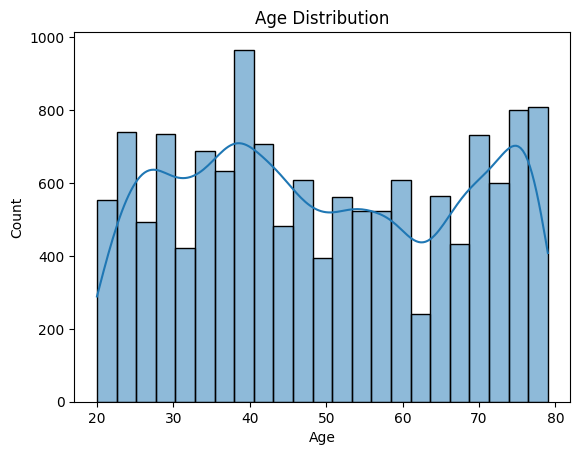

In [ ]:
#initial information
plt.title("Gender Distribution")
sns.histplot(df["Age"], kde=True)
plt.title("Age Distribution")
plt.show()

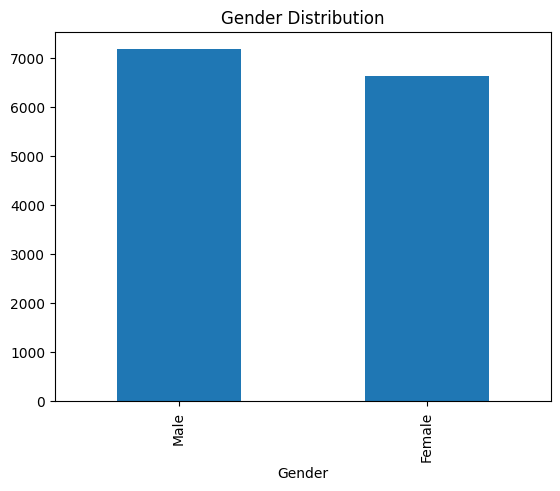

In [81]:
df["Gender"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.show()